# Imports

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import rc
import numpy as np
rc('font',size=18)

In [2]:
#from pynitride.devices import gan_pfet
from pynitride.paramdb import nm,cm, k, eV
from pynitride.solvers import PoissonSolver, Equilibrium, SelfConsistentLoop, Linear_Fermi
from pynitride.carriers import Semiclassical, Schrodinger, MultibandKP
from pynitride.visual import sublog
from pynitride.devices import gan_pfet_SiO2

In [3]:
from scipy.constants import e as elemcharge

# Schrodinger

Starting eps factor ramp from 10000 to 1
  Eps factor: 1.00e+04
  Starting SC loop
    iter:   0  err: 1.35e-17  activ: 1
    Loop finished in  1 iterations with err=1.34816e-17
  Eps factor: 6.31e+03
  Starting SC loop
    iter:   0  err: 3.35e-04  activ: 1
    iter:   1  err: 6.04e-17  activ: 1
    Loop finished in  2 iterations with err=6.04057e-17
  Eps factor: 2.51e+03
  Starting SC loop
    iter:   0  err: 1.37e-03  activ: 1
    iter:   1  err: 4.90e-16  activ: 1
    Loop finished in  2 iterations with err=4.89674e-16
  Eps factor: 7.94e+02
  Starting SC loop
    iter:   0  err: 4.93e-03  activ: 1
    iter:   1  err: 5.70e-15  activ: 1
    Loop finished in  2 iterations with err=5.70057e-15
  Eps factor: 2.51e+02
  Starting SC loop
    iter:   0  err: 1.56e-02  activ: 1
    iter:   1  err: 1.40e-14  activ: 1
    Loop finished in  2 iterations with err=1.4018e-14
  Eps factor: 7.94e+01
  Starting SC loop
    iter:   0  err: 4.93e-02  activ: 1
    iter:   1  err: 8.91e-14  activ: 1

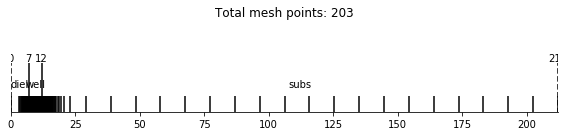

In [4]:
m,[clm1,scm,clm2]=gan_pfet_SiO2(7*nm,5*nm,200*nm,Ndef=5e16/cm**3,surface=2*eV)

#
from pynitride.mesh import PointFunction
m['fc']=PointFunction(m,0.0)
idw=m.interfaces_point[0][0]
m.fc[idw]=4.5e13/(1e7)**2/m.dzm[idw]
#

#Equilibrium(m)
Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-3,idw=0,source=0,subs=0))
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Semiclassical(clm1),Schrodinger(scm),Semiclassical(clm2)])
scl.ramp_epsfactor(max_iter=20,dlefmin=.01)
m.plot_mesh()

In [5]:
m._functions.keys()

dict_keys(['T', 'x', 'SiO2', 'SiDonorConc', 'MgAcceptorConc', 'fc', 'EF', 'Ndp', 'Nam', 'Ndpderiv', 'Namderiv', 'eps', 'phi', 'DE', 'exx', 'eyy', 'C13', 'C33', 'ezz', 'exy', 'eyz', 'exz', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'DeltaSO', 'DeltaCR', 'a1', 'a2', 'Delta1', 'Delta2', 'Delta3', 'Eg', 'E0-Ev', 'Ec-E0', 'EvOffset', 'Ec', 'Ev', 'E', 'D', 'SiDonorg', 'SiDonorE', 'MgAcceptorg', 'MgAcceptorE', 'Psp', 'e31', 'e33', 'P', 'DP', 'rho', 'rhoderiv', 'p', 'pderiv', 'n', 'nderiv'])

In [6]:
m.SiDonorConc,m.SiDonorConc[-3]

(Function([  0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
          0.00000000e+00,   0.00000000e+00,   0.00000000e+00,
     

Text(0.5,0,'Depth [nm]')

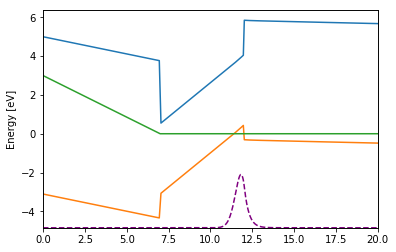

In [8]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)
plt.ylabel("Energy [eV]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--',color='purple')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
plt.xlim(0,20)
plt.ylim(0,.4e21)
plt.yticks([])
plt.xlabel("Depth [nm]")

In [88]:
m.p.integrate(definite=True) /(1/cm**2) /1e13

Function(0.9401321510100615)

In [176]:
surfs=[1.5,1,.5]
sres=[]
for phib in surfs:
    res=[]
    thicks=[1,2,2.5,2.75,3,3.25,3.5,3.75,4,4.25,4.5,5,6,7,8,9,10,12.5,15,17.5,20,25,30,40]#np.linspace(1*nm,40*nm,10)
    for t in thicks:
        with sublog("Thickness: "+str(t/nm)+" nm"):
            m,[scm,clm]=gan_pfet(t,200*nm,Ndef=5e16/cm**3,surface=phib)
            Equilibrium(m)
            scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Schrodinger(scm),Semiclassical(clm)])
            scl.ramp_epsfactor(max_iter=20,dlefmin=.01)
            res+=[m]
    sres+=[res]

Thickness: 1.0 nm
  Starting eps factor ramp from 10000 to 1
    Eps factor: 1.00e+04
    Starting SC loop
      iter:   0  err: 3.73e-18  activ: 1
      Loop finished in  1 iterations with err=3.73098e-18
    Eps factor: 6.31e+03
    Starting SC loop
      iter:   0  err: 6.76e-05  activ: 1
      iter:   1  err: 6.28e-19  activ: 1
      Loop finished in  2 iterations with err=6.27698e-19
    Eps factor: 2.51e+03
    Starting SC loop
      iter:   0  err: 2.77e-04  activ: 1
      iter:   1  err: 1.26e-17  activ: 1
      Loop finished in  2 iterations with err=1.26094e-17
    Eps factor: 7.94e+02
    Starting SC loop
      iter:   0  err: 9.95e-04  activ: 1
      iter:   1  err: 1.17e-16  activ: 1
      Loop finished in  2 iterations with err=1.16834e-16
    Eps factor: 2.51e+02
    Starting SC loop
      iter:   0  err: 3.15e-03  activ: 1
      iter:   1  err: 1.54e-16  activ: 1
      Loop finished in  2 iterations with err=1.53657e-16
    Eps factor: 7.94e+01
    Starting SC loop
    

      iter:   1  err: 4.58e-15  activ: 1
      Loop finished in  2 iterations with err=4.58395e-15
    Eps factor: 7.94e+00
    Starting SC loop
      iter:   0  err: 2.19e-01  activ: 1
      iter:   1  err: 2.06e-14  activ: 1
      Loop finished in  2 iterations with err=2.059e-14
    Eps factor: 2.51e+00
    Starting SC loop
      iter:   0  err: 6.91e-01  activ: 1
      iter:   1  err: 5.67e-14  activ: 1
      Loop finished in  2 iterations with err=5.66927e-14
    Eps factor: 1.00e+00
    Starting SC loop
      iter:   0  err: 1.53e+00  activ: 1
      iter:   1  err: 2.11e-02  activ: 1
      iter:   2  err: 7.50e-03  activ: 1
      iter:   3  err: 6.09e-04  activ: 1
      iter:   4  err: 7.19e-06  activ: 1
      iter:   5  err: 1.53e-07  activ: 1
      Loop finished in  6 iterations with err=1.52807e-07
    Done eps factor ramp
Thickness: 3.25 nm
  Starting eps factor ramp from 10000 to 1
    Eps factor: 1.00e+04
    Starting SC loop
      iter:   0  err: 2.52e-17  activ: 1
      L

      iter:   0  err: 7.10e-04  activ: 1
      iter:   1  err: 1.29e-16  activ: 1
      Loop finished in  2 iterations with err=1.29239e-16
    Eps factor: 7.94e+02
    Starting SC loop
      iter:   0  err: 2.55e-03  activ: 1
      iter:   1  err: 4.42e-16  activ: 1
      Loop finished in  2 iterations with err=4.41881e-16
    Eps factor: 2.51e+02
    Starting SC loop
      iter:   0  err: 8.07e-03  activ: 1
      iter:   1  err: 1.12e-15  activ: 1
      Loop finished in  2 iterations with err=1.1201e-15
    Eps factor: 7.94e+01
    Starting SC loop
      iter:   0  err: 2.55e-02  activ: 1
      iter:   1  err: 1.77e-15  activ: 1
      Loop finished in  2 iterations with err=1.76752e-15
    Eps factor: 2.51e+01
    Starting SC loop
      iter:   0  err: 8.07e-02  activ: 1
      iter:   1  err: 1.07e-14  activ: 1
      Loop finished in  2 iterations with err=1.06858e-14
    Eps factor: 7.94e+00
    Starting SC loop
      iter:   0  err: 2.55e-01  activ: 1
      iter:   1  err: 2.37e-14

    Eps factor: 1.41e+00
    Starting SC loop
      iter:   0  err: 1.83e-01  activ: 1
      iter:   1  err: 6.29e-02  activ: 1
      iter:   2  err: 9.35e-02  activ: 1
      Retrying with Poisson activation=0.5
             iter:   2  err: 1.39e-01
      Retrying with Poisson activation=0.25
             iter:   2  err: 1.51e-01
      Retrying with Poisson activation=0.125
             iter:   2  err: 1.44e-01
      Retrying with Poisson activation=0.0625
    Failure: Couldn't reduce error in SC loop
    Restoring at 2.51e+00
    Eps factor: 1.88e+00
    Starting SC loop
      iter:   0  err: 3.16e-01  activ: 1
      iter:   1  err: 1.58e-08  activ: 1
      Loop finished in  2 iterations with err=1.57926e-08
    Eps factor: 1.06e+00
    Starting SC loop
      iter:   0  err: 1.31e+00  activ: 1
      iter:   1  err: 2.77e-01  activ: 1
      iter:   2  err: 1.06e-01  activ: 1
      iter:   3  err: 5.82e-02  activ: 1
      iter:   4  err: 4.74e-02  activ: 1
      iter:   5  err: 4.32e-02

      iter:   1  err: 5.87e-02  activ: 1
      iter:   2  err: 8.26e-02  activ: 1
      Retrying with Poisson activation=0.5
             iter:   2  err: 7.93e-02
      Retrying with Poisson activation=0.25
             iter:   2  err: 7.35e-02
      Retrying with Poisson activation=0.125
             iter:   2  err: 7.09e-02
      Retrying with Poisson activation=0.0625
    Failure: Couldn't reduce error in SC loop
    Restoring at 1.63e+00
    Eps factor: 1.52e+00
    Starting SC loop
      iter:   0  err: 1.37e-01  activ: 1
      iter:   1  err: 7.00e-03  activ: 1
      iter:   2  err: 4.22e-07  activ: 1
      Loop finished in  3 iterations with err=4.22451e-07
    Eps factor: 1.31e+00
    Starting SC loop
      iter:   0  err: 3.45e-01  activ: 1
      iter:   1  err: 4.25e-02  activ: 1
      iter:   2  err: 3.08e-02  activ: 1
      iter:   3  err: 1.68e-02  activ: 1
      iter:   4  err: 4.68e-03  activ: 1
      iter:   5  err: 3.33e-04  activ: 1
      iter:   6  err: 7.60e-06  act

...

      iter:   1  err: 7.60e-03  activ: 1
      iter:   2  err: 3.71e-03  activ: 1
      iter:   3  err: 1.79e-03  activ: 1
      iter:   4  err: 8.50e-04  activ: 1
      iter:   5  err: 3.99e-04  activ: 1
      iter:   6  err: 1.86e-04  activ: 1
      iter:   7  err: 8.69e-05  activ: 1
      iter:   8  err: 4.05e-05  activ: 1
      iter:   9  err: 1.89e-05  activ: 1
      iter:  10  err: 8.79e-06  activ: 1
      iter:  11  err: 4.09e-06  activ: 1
      iter:  12  err: 1.91e-06  activ: 1
      iter:  13  err: 8.89e-07  activ: 1
      Loop finished in 14 iterations with err=8.88939e-07
    Done eps factor ramp
Thickness: 17.5 nm
  Starting eps factor ramp from 10000 to 1
    Eps factor: 1.00e+04
    Starting SC loop
      iter:   0  err: 1.10e-13  activ: 1
      Loop finished in  1 iterations with err=1.10292e-13
    Eps factor: 6.31e+03
    Starting SC loop
      iter:   0  err: 8.66e-04  activ: 1
      iter:   1  err: 7.31e-15  activ: 1
      Loop finished in  2 iterations with err=7.3

      iter:   5  err: 1.65e-06  activ: 1
      iter:   6  err: 3.08e-07  activ: 1
      Loop finished in  7 iterations with err=3.0796e-07
    Eps factor: 1.75e+00
    Starting SC loop
      iter:   0  err: 4.15e-01  activ: 1
      iter:   1  err: 1.55e-02  activ: 1
      iter:   2  err: 3.44e-03  activ: 1
      iter:   3  err: 1.01e-03  activ: 1
      iter:   4  err: 3.56e-04  activ: 1
      iter:   5  err: 1.25e-04  activ: 1
      iter:   6  err: 4.39e-05  activ: 1
      iter:   7  err: 1.54e-05  activ: 1
      iter:   8  err: 5.41e-06  activ: 1
      iter:   9  err: 1.90e-06  activ: 1
      iter:  10  err: 6.68e-07  activ: 1
      Loop finished in 11 iterations with err=6.67867e-07
    Eps factor: 1.00e+00
    Starting SC loop
      iter:   0  err: 8.14e-01  activ: 1
      iter:   1  err: 1.49e-02  activ: 1
      iter:   2  err: 7.14e-03  activ: 1
      iter:   3  err: 3.46e-03  activ: 1
      iter:   4  err: 1.64e-03  activ: 1
      iter:   5  err: 7.65e-04  activ: 1
      iter:   

      iter:   9  err: 4.11e-05  activ: 1
      iter:  10  err: 1.93e-05  activ: 1
      iter:  11  err: 9.03e-06  activ: 1
      iter:  12  err: 4.24e-06  activ: 1
      iter:  13  err: 1.99e-06  activ: 1
      iter:  14  err: 9.35e-07  activ: 1
      Loop finished in 15 iterations with err=9.34508e-07
    Done eps factor ramp
Thickness: 25.0 nm
  Starting eps factor ramp from 10000 to 1
    Eps factor: 1.00e+04
    Starting SC loop
      iter:   0  err: 1.32e-13  activ: 1
      Loop finished in  1 iterations with err=1.32449e-13
    Eps factor: 6.31e+03
    Starting SC loop
      iter:   0  err: 1.24e-03  activ: 1
      iter:   1  err: 1.64e-15  activ: 1
      Loop finished in  2 iterations with err=1.64056e-15
    Eps factor: 2.51e+03
    Starting SC loop
      iter:   0  err: 5.07e-03  activ: 1
      iter:   1  err: 1.99e-14  activ: 1
      Loop finished in  2 iterations with err=1.99342e-14
    Eps factor: 7.94e+02
    Starting SC loop
      iter:   0  err: 1.82e-02  activ: 1
     

      iter:   0  err: 2.17e+00  activ: 1
      iter:   1  err: 1.33e+00  activ: 1
      iter:   2  err: 4.06e-01  activ: 1
      iter:   3  err: 1.44e-01  activ: 1
      iter:   4  err: 9.90e-02  activ: 1
      iter:   5  err: 1.33e-01  activ: 1
      Retrying with Poisson activation=0.5
             iter:   5  err: 2.36e-01
      Retrying with Poisson activation=0.25
             iter:   5  err: 2.98e-01
      Retrying with Poisson activation=0.125
             iter:   5  err: 3.20e-01
      Retrying with Poisson activation=0.0625
    Failure: Couldn't reduce error in SC loop
    Restoring at 7.94e+00
    Eps factor: 4.47e+00
    Starting SC loop
      iter:   0  err: 1.01e+00  activ: 1
      iter:   1  err: 3.18e-01  activ: 1
      iter:   2  err: 1.38e-01  activ: 1
      iter:   3  err: 1.24e-01  activ: 1
      iter:   4  err: 2.69e-01  activ: 1
      Retrying with Poisson activation=0.5
             iter:   4  err: 2.84e-01
      Retrying with Poisson activation=0.25
             i

             iter:   4  err: 2.54e-01
      Retrying with Poisson activation=0.125
             iter:   4  err: 2.46e-01
      Retrying with Poisson activation=0.0625
    Failure: Couldn't reduce error in SC loop
    Restoring at 1.41e+01
    Eps factor: 1.06e+01
    Starting SC loop
      iter:   0  err: 2.95e-01  activ: 1
      iter:   1  err: 1.50e-01  activ: 1
      iter:   2  err: 1.43e-01  activ: 1
      iter:   3  err: 1.38e-01  activ: 1
      iter:   4  err: 1.42e-01  activ: 1
      Retrying with Poisson activation=0.5
             iter:   4  err: 1.56e-01
      Retrying with Poisson activation=0.25
             iter:   4  err: 1.68e-01
      Retrying with Poisson activation=0.125
             iter:   4  err: 1.69e-01
      Retrying with Poisson activation=0.0625
    Failure: Couldn't reduce error in SC loop
    Restoring at 1.41e+01
    Eps factor: 1.22e+01
    Starting SC loop
      iter:   0  err: 3.04e-01  activ: 1
      iter:   1  err: 1.67e-02  activ: 1
      iter:   2  e

In [123]:
surfs

[1.5, 1, 0.5]

Text(0.5,0,'Well thickness [nm]')

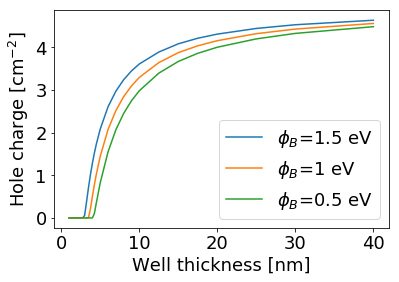

In [143]:
for phib,res in zip(surfs,sres):
    ps=[m.p.integrate(definite=True)/(1/cm**2)  /1e13 for m in res]
    plt.plot(thicks,ps,label="$\phi_B$={:.2g} eV".format(phib))
plt.legend()
plt.ylabel("Hole charge [cm$^{-2}$]")
plt.xlabel("Well thickness [nm]")
#plt.xlim(0,5)

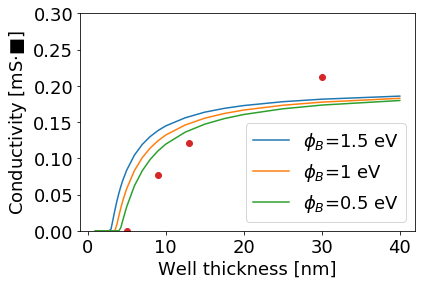

In [173]:
for phib,res in zip(surfs,sres):
    ps=np.array([m.p.integrate(definite=True)/(1/cm**2)  /1e13 for m in res])
    ss=(elemcharge*ps*1e13*25)
    plt.plot(thicks,ss*1e3,label="$\phi_B$={:.2g} eV".format(phib))
plt.legend(loc='lower right')
plt.ylabel("Conductivity [mS$\\cdot\\blacksquare$]")
plt.xlabel("Well thickness [nm]")
plt.ylim(0,.3)
plt.plot([30,13,9,5],[1000/4712,1000/8272,1000/13050,0],'o')
#plt.xlim(0,5)

In [142]:
print("Thicknesses [nm]: ")
print(thicks)
print("\n\n")

for phib,res in zip(surfs,sres):
    print("Surface barrier [eV]: ",phib)
    print("Hole charge [x1e13/cm^2]:")
    ps=[m.p.integrate(definite=True)/(1/cm**2)  /1e13 for m in res]
    print(np.array(ps))

Thicknesses [nm]: 
[1, 2, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4, 4.25, 4.5, 5, 6, 7, 8, 9, 10, 12.5, 15, 17.5, 20, 25, 30, 40]



Surface barrier [eV]:  1.5
Hole charge [x1e13/cm^2]:
[  1.23692628e-32   1.15844541e-15   1.30362181e-08   4.66301590e-05
   5.90539214e-02   3.83496704e-01   7.19575362e-01   1.02075592e+00
   1.28728427e+00   1.52270118e+00   1.73165831e+00   2.08486191e+00
   2.60757141e+00   2.97344069e+00   3.24293987e+00   3.44919277e+00
   3.61191271e+00   3.89226750e+00   4.08594353e+00   4.21696194e+00
   4.31369317e+00   4.44660470e+00   4.53340312e+00   4.63917292e+00]
Surface barrier [eV]:  1
Hole charge [x1e13/cm^2]:
[  4.92847816e-41   8.63449893e-27   1.11567812e-19   1.85646440e-13
   6.67098103e-10   2.39769560e-06   7.39173638e-03   2.19410726e-01
   5.10111078e-01   7.81284962e-01   1.02659721e+00   1.44649074e+00
   2.07478997e+00   2.51785292e+00   2.84562447e+00   3.09724114e+00
   3.29621469e+00   3.64441160e+00   3.87833349e+00   4.03989991e+00
   4.159422

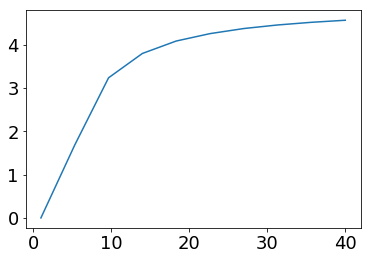

(0, 40)

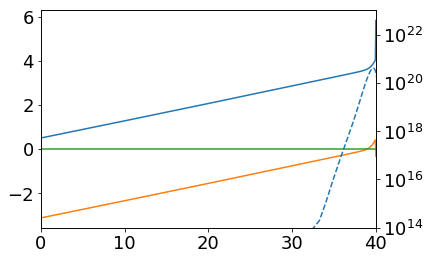

In [175]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,40)

NameError: name 'sw' is not defined

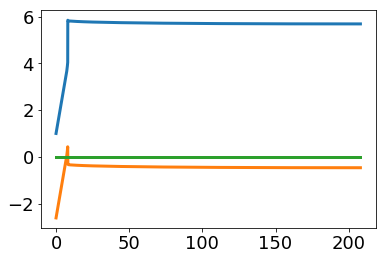

In [16]:
plt.figure()
plt.plot(m.zp,m.Ec,linewidth=3)
plt.plot(m.zp,m.Ev,linewidth=3)
plt.plot(m.zp,m.EF,linewidth=3)
plt.plot(scm.zp,sw[:,:1,0])
plt.plot(scm.zp,sw[:,:1,1])
plt.plot(scm.zp,sw[:,:1,2])
plt.plot(scm.zp,scm.hen.T[:,0,:],'--')
plt.ylim(-.5,.75)
plt.ylabel("Energy [eV]")
plt.xlabel("Depth [nm]")

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'-')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('lin')
#plt.ylim(1e14,1e23)
plt.ylabel("Carrier density [cm$^{-3}$]")
plt.xlim(5,11.9)

In [14]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(2.9264562392388207)

# KPSolver

In [12]:
m,[scm,clm]=gan_pfet(8*nm,200*nm,Ndef=5e16/cm**3,)

In [13]:
Equilibrium(m)

In [14]:
m.ztrans

-1

In [15]:
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[MultibandKP(scm),Semiclassical(scm,'electron'),Semiclassical(clm)])

Assembling k.p matrices ...
Done assembly.


In [16]:
%%timeit -n 1 -r 1
scl.ramp_epsfactor(start=1e1,max_iter=30)

Starting eps factor ramp from 10 to 1
  Eps factor: 1.00e+01
  Starting SC loop
    iter:   0  err: 2.23e-14  activ: 1
    Loop finished in  1 iterations with err=2.22602e-14
  Eps factor: 6.31e+00
  Starting SC loop
    iter:   0  err: 3.96e-01  activ: 1
    iter:   1  err: 1.71e-13  activ: 1
    Loop finished in  2 iterations with err=1.71083e-13
  Eps factor: 2.51e+00
  Starting SC loop
    iter:   0  err: 1.62e+00  activ: 1
    iter:   1  err: 2.13e-03  activ: 1
    iter:   2  err: 6.90e-06  activ: 1
    iter:   3  err: 4.53e-10  activ: 1
    Loop finished in  4 iterations with err=4.53433e-10
  Eps factor: 1.00e+00
  Starting SC loop
    iter:   0  err: 3.40e+00  activ: 1
    iter:   1  err: 4.27e+01  activ: 1
    Retrying with Poisson activation=0.5
           iter:   1  err: 8.69e+00
    Retrying with Poisson activation=0.25
           iter:   1  err: 7.22e+00
    Retrying with Poisson activation=0.125
           iter:   1  err: 6.61e+00
    Retrying with Poisson activation=0.06

Exception: Eps factor step size too small

(0, 20)

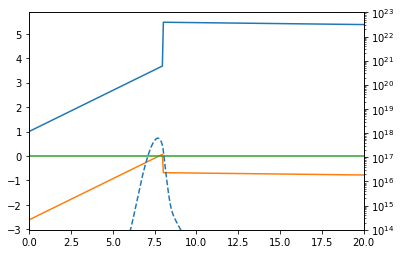

In [17]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

<function matplotlib.pyplot.plot(*args, **kwargs)>

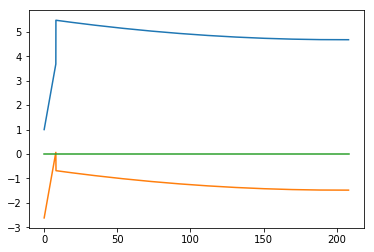

In [18]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
#plt.xlim(0,20)

In [20]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(0.004135477914228135)

# Schro then KPSolver

In [26]:
from pynitride.visual import log
import numpy as np
log._depth=0
log._showlevel=np.inf

In [27]:
m,[clm1,scm,clm2]=gan_pfet_SiO2(xd=7*nm,xw=5*nm,xs=200*nm,Ndef=5e16/cm**3,)

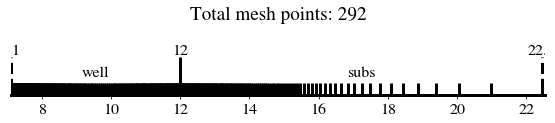

In [28]:
scm.plot_mesh()

In [29]:
from pynitride.mesh import PointFunction
m['fc']=PointFunction(m,0.0)
idw=m.interfaces_point[0][0]
m.fc[idw]=4.7e13/(1e7)**2/m.dzm[idw]

In [30]:
#Equilibrium(m)
Linear_Fermi(m,contacts={'gate':0,'idw':1,'source':2,'subs':3}).solve(**dict(gate=-5,idw=0,source=0,subs=0))

In [31]:
#%%timeit -n 1 -r 1
scl=SelfConsistentLoop(fieldsolvers=[PoissonSolver(m)],carriersolvers=[Semiclassical(clm1),Schrodinger(scm,'hole'),Semiclassical(scm,'electron'),Semiclassical(clm2)])
scl.ramp_epsfactor(start=1e3,max_iter=20,dlefmin=.01)
#mbkp=MultibandKP(scm)
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
#for cs in [mbkp,Schrodinger(scm,'electron'),Semiclassical(clm)]:
#    cs.solve()
#print(scl._fs[0].isolve())
psm=PoissonSolver(m)
psm.solve()
if 1:
    mbkp=MultibandKP(scm,ktmax=2.5,num_kpoints=30)
    for H in mbkp._H:
        H[:6,:6]*=2
        H[-6:,-6:]*=2
    scl=SelfConsistentLoop(fieldsolvers=[psm],carriersolvers=[mbkp,Semiclassical(clm1),Semiclassical(scm,'electron'),Semiclassical(clm2)])
    scl.loop(tol=1e-8)

Using explicit masses from file
Using explicit masses from file
Using explicit masses from file
Starting eps factor ramp from 1000 to 1
  Eps factor: 1.00e+03
  Poisson iSolve
  Starting SC loop
    Poisson iSolve
    Expanding function p
    Expanding function pderiv
    Expanding function n
    Expanding function nderiv
    iter:   0  err: 8.60e-02  activ: 1
    Poisson iSolve
    iter:   1  err: 7.20e-03  activ: 1
    Poisson iSolve
    iter:   2  err: 3.39e-05  activ: 1
    Poisson iSolve
    iter:   3  err: 6.36e-09  activ: 1
    Loop finished in  4 iterations with err=6.35565e-09
  Eps factor: 6.31e+02
  Poisson iSolve
  Starting SC loop
    Poisson iSolve
    iter:   0  err: 2.18e-02  activ: 1
    Poisson iSolve
    iter:   1  err: 4.14e-04  activ: 1
    Poisson iSolve
    iter:   2  err: 1.40e-07  activ: 1
    Loop finished in  3 iterations with err=1.39993e-07
  Eps factor: 2.51e+02
  Poisson iSolve
  Starting SC loop
    Poisson iSolve
    iter:   0  err: 3.95e-02  activ: 1
 

(0, 20)

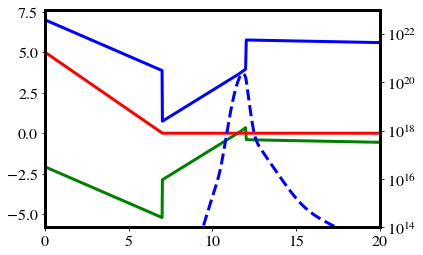

In [32]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.twinx()
plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.pderiv*k*m.T.tpf()/(1/cm**3),'.--')
plt.plot(m.zp,m.n/(1/cm**3),'--')
plt.yscale('log')
plt.ylim(1e14,1e23)
plt.xlim(0,20)

In [33]:
print(m.p.integrate(definite=True)/(1/cm**2)/1e13)

1.225482039886735


# Make GOMAC FIG

In [34]:
import matplotlib.pyplot as plt
import numpy as np
#from jxhfet.util import oldcolors; oldcolors()
from matplotlib.transforms import Bbox
from matplotlib.patches import Rectangle,Ellipse,Polygon
from matplotlib.lines import Line2D
from matplotlib.collections import PatchCollection
import matplotlib.transforms as transforms
from cycler import cycler

In [35]:
plt.rcParams['axes.linewidth']=3
plt.rcParams['lines.linewidth']=3
plt.rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif']=['STIX']
plt.rcParams['mathtext.fontset']='stix'
plt.rcParams['font.size']=16
plt.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')

## BD

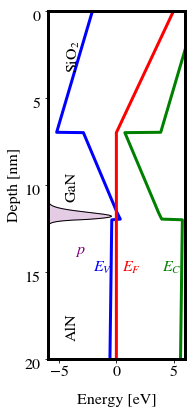

In [46]:
def fig_pFET_bd(ax):
    ax.plot(m.Ev,m.zp)
    ax.plot(m.Ec,m.zp)
    ax.plot(m.EF,m.zp)
    ax.set_yticks(np.linspace(0,20,5))
    ax.set_ylim(20,0)
    ax.set_ylabel("Depth [nm]")
    #plt.gca().yaxis.set_label_position("right")
    #plt.gca().yaxis.tick_right()
    ax.set_xlim(-6,6)
    plt.setp(ax.get_yticklabels(),va='top')
    #plt.gca().add_artist(Ellipse((-4,5.5),3,6,facecolor='none',edgecolor='k'))
    #plt.gca().add_artist(Ellipse((5,5.5),3,6,facecolor='none',edgecolor='k'))
    
    ax.set_xlabel("Energy [eV]")
    ax.xaxis.set_label_coords(.5,-.1)
    ax.text(4,15,"$E_C$",color='g',transform=ax.transData)
    ax.text(-2,15,"$E_V$",color='b',transform=ax.transData)
    ax.text(.5,15,"$E_F$",color='r',transform=ax.transData)
    
    ax2=ax.twiny()
    xmax=500
    ax2.plot(m.p*(1e7)**3/1e18,m.zp,'k',linewidth=1)
    ax2.fill_betweenx(m.zp,m.p*(1e7)**3/1e18,color='purple',alpha=.2)
    ax2.set_xlim(0,xmax)
    ax2.set_xticks([])
    ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)

    if 0:
        hl=nno.read(nno.dir+"/densities/density1Dhl"+suffix+".dat")
        el=nno.read(nno.dir+"/densities/density1Del"+suffix+".dat")
        ax2.plot(hl['hl[1e18/cm3]'],hl['position[nm]'],'k',linewidth=1)
        ax2.plot(xmax-el['el[1e18/cm3]'],el['position[nm]'],'k',linewidth=1)
        ax2.fill_betweenx(hl['position[nm]'],hl['hl[1e18/cm3]'],color='purple',alpha=.2)
        ax2.fill_betweenx(el['position[nm]'],xmax-el['el[1e18/cm3]'],x2=xmax,color='orange',alpha=.6)
        ax2.set_xlim(0,xmax)
        ax2.set_xticks([])
        ax2.text(100,14,"$p$",color='purple',transform=ax2.transData)
        #print("hl {:.2g}x10^13/cm^2".format(np.trapz(hl['hl[1e18/cm3]']*1e18*1e-7,hl['position[nm]'])/1e13))
        #print("el {:.2g}x10^13/cm^2".format(np.trapz(el['el[1e18/cm3]']*1e18*1e-7,el['position[nm]'])/1e13))

    ax2.text(.13,.05,"AlN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.45,"GaN",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')
    ax2.text(.13,.82,"SiO$_2$",transform=ax2.transAxes, rotation=90, ha='left', va='bottom')

fig=plt.figure(figsize=(3,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_bd(ax)
plt.tight_layout()    
plt.savefig('pFET_bd.png')

## disp

In [37]:
from scipy import gradient
from scipy.interpolate import interp1d
from matplotlib.transforms import Bbox

In [38]:
def DOS_of_one(k_t,bs1_t,E):
    kt2=np.ravel(interp1d(np.ravel(bs1_t),np.ravel(k_t)**2,fill_value=0,bounds_error=False,kind='quadratic')(E))
    N=1/(2*np.pi)**2 * np.pi *kt2
    DOS=gradient(N,E[1]-E[0])
    return -DOS
E=np.linspace(.1,-.1,1200)
DOS=0

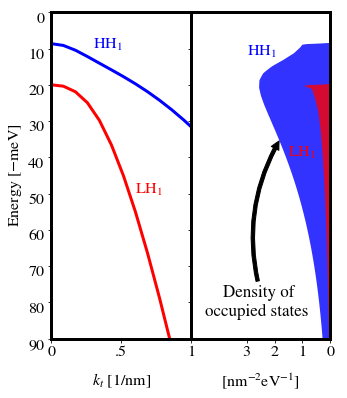

In [48]:
def fig_pFET_disp(ax):

    ax.axis('off')
    ax1=plt.axes(Bbox.from_extents(0,0,.5,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()))
    ax2=plt.axes(Bbox.from_extents(.5,0,1,1).transformed(ax.transAxes+ax.figure.transFigure.inverted()),sharey=ax1)
    
    ### Dispersion plot
    
    # Plot the first two levels
    k1,e1=mbkp._kt,mbkp._mesh.kpen[:,0,0]
    ax1.plot(k1,-e1*1e3,'b',label="HH-1")
    k3,e3=mbkp._kt,mbkp._mesh.kpen[:,2,0]
    ax1.plot(k3,-e3*1e3,'r',label="LH-1")
    
    # Also plot the next level to make sure it's offscreen!
    #ax1.plot(disp_hg['k[1/nm]'],disp_hg['ev_5[eV]']*1e3,'b',label="HH-2")
    
    # Extract DOS
    DOS1=2*DOS_of_one(k1,e1,E)
    DOS3=2*DOS_of_one(k3,e3,E)
    
    # Label bands
    ax1.text(.3,10,r"HH$_1$",color='b',transform=ax1.transData)
    ax1.text(.6,50,r"LH$_1$",color='r',transform=ax1.transData)
    #ax1.text(.4,-8,r"$E_F$",color='k',transform=ax1.transData)
    ax1.axhline(0,linestyle='--',color='k')
    
    # Label axes
    ax1.yaxis.set_label_text(r"Energy [$-$meV]")
    #ax1.yaxis.set_label_coords(-.2,.72)
    ax1.xaxis.set_label_text(r"$k_t$ [1/nm]")
    ax1.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax1.get_yticklabels(),va='top')
    
    # Set limits and ticks
    ax1.set_ylim(90,0);
    ax1.set_xlim(0,1)
    ax1.set_xticks([0,.5,1])
    ax1.set_xticklabels(["0",".5","1"])

    ### DOS plot
    
    # Plot occupieds
    ax2.fill_betweenx(-E*1e3,DOS1*(1/(1+np.exp(-E/.026))),0,facecolor='b',edgecolor='k',linewidth=0,alpha=.8,label='HH-1')
    ax2.fill_betweenx(-E*1e3,(DOS3)*(1/(1+np.exp(-E/.026))),0,facecolor='r',edgecolor='k',linewidth=0,alpha=.8,label='LH-1')
    ax2.axhline(0,linestyle='--',color='k')
    
    # Label and set limits
    ax2.set_xlim(5,0)
    ax2.set_xticks([0,1,2,3])
    ax2.set_xlabel("[nm$^{-2}$eV$^{-1}$]")
    ax2.xaxis.set_label_position("bottom")
    ax2.xaxis.tick_bottom()
    ax2.xaxis.set_label_coords(.5,-.1)
    plt.setp(ax2.get_yticklabels(),visible=False)

    # Label DOSs
    plt.text(3,12,r"HH$_1$",color='b')
    plt.text(1.5,40,r"LH$_1$",color='r')

    plt.annotate("Density of\noccupied states ",(1.8,35),xytext=(2.57,80),ha='center',va='center',fontsize=17,
                 arrowprops=dict(arrowstyle='simple',color='k',connectionstyle='arc3,rad=-.2',relpos=(.5,1)))

fig=plt.figure(figsize=(5,6),frameon=False)
ax=plt.subplot(111)
fig_pFET_disp(ax)
#plt.tight_layout()
plt.savefig("pFET_disp.png")

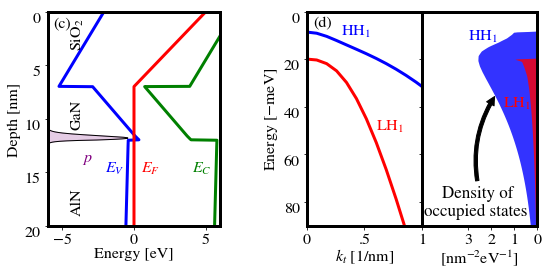

In [49]:
fig=plt.figure(figsize=(8,3.5),frameon=False)
ax1=fig.add_axes(plt.Axes(plt.gcf(),[.1,.15,.3,.85]))
ax2=fig.add_axes(plt.Axes(plt.gcf(),[.55,.15,.4,.85]))
fig_pFET_bd(ax1)
fig_pFET_disp(ax2)
ax1.text(.03,.93,"(c)",transform=ax1.transAxes)
ax2.figure.axes[-1].text(.03,.93,"(d)",transform=ax2.transAxes)
plt.savefig("pFET_theory.png")

(0, 10)

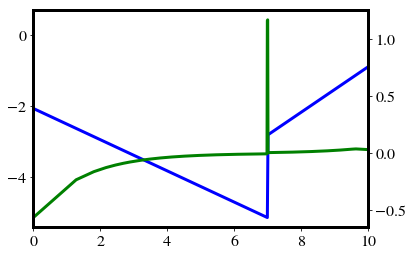

In [22]:
plt.plot(m.zp,m.Ev)
plt.twinx()
plt.plot(m.zp[:-1],np.diff(m.Ev),color='g')
plt.xlim(0,10)

In [23]:
m.Ev[138:144]

Function([-5.14530785, -5.14978091, -5.15422253, -3.9909826 , -2.82103519,
       -2.81459182])

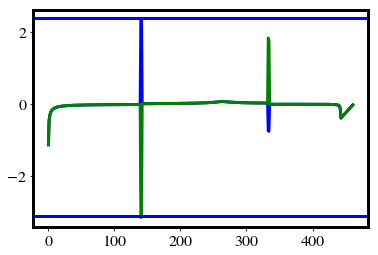

In [25]:
plt.plot(2*np.diff(m.Ev))
plt.plot(2*np.diff(m.Ec))
plt.axhline(-3)
plt.axhline(2.4)
#plt.ylim(-3,2.4)

# IDK?

(-1.5, 1)

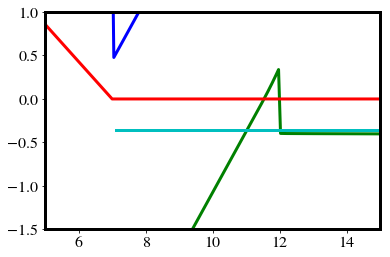

In [127]:
plt.figure()
plt.plot(m.zp,m.Ec)
plt.plot(m.zp,m.Ev)
plt.plot(m.zp,m.EF)

plt.plot(scm.zp,scm.kpen[14,12].T)

#plt.twinx()
#plt.plot(m.zp,m.p/(1/cm**3),'--')
#plt.plot(m.zp,m.n/(1/cm**3),'--')
#plt.yscale('log')
#plt.ylim(1e14,1e23)
plt.xlim(5,15)
plt.ylim(-1.5,1)

In [28]:
mbkp.solve()

MBKP Solve
not blending


In [29]:
np.max(np.abs(mbkp._H[10][:12,:12].todense()-mbkp._H[10][:12,:12].todense().H))

0.0

(-0.8, 0.1)

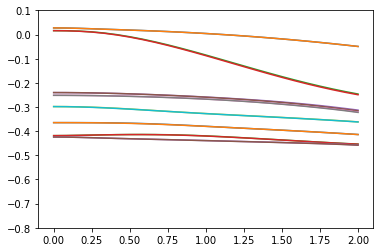

In [30]:
plt.figure()
plt.plot(mbkp._kt,scm.kpen[:,0,0],)
plt.plot(mbkp._kt,scm.kpen[:,1,0],)
plt.plot(mbkp._kt,scm.kpen[:,2,0],)
plt.plot(mbkp._kt,scm.kpen[:,3,0],)
plt.plot(mbkp._kt,scm.kpen[:,4,0],)
plt.plot(mbkp._kt,scm.kpen[:,5,0],)
plt.plot(mbkp._kt,scm.kpen[:,6,0],)
plt.plot(mbkp._kt,scm.kpen[:,7,0],)
plt.plot(mbkp._kt,scm.kpen[:,8,0],)
plt.plot(mbkp._kt,scm.kpen[:,9,0],)
plt.plot(mbkp._kt,scm.kpen[:,10,0],)
plt.plot(mbkp._kt,scm.kpen[:,11,0],)
plt.plot(mbkp._kt,scm.kpen[:,12,0],)
plt.plot(mbkp._kt,scm.kpen[:,13,0],)
plt.plot(mbkp._kt,scm.kpen[:,14,0],)
plt.plot(mbkp._kt,scm.kpen[:,15,0],)

plt.ylim(-.8,.1)

-0.49388306460524517

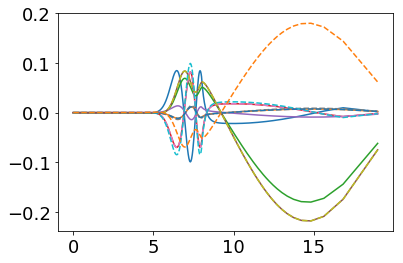

In [79]:
plt.figure()
kti=14
e=12
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,0,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,1,:])) #big
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,2,:])) #nothing
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,3,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,4,:])) #smaller
plt.plot(scm.zp,np.real(scm.kppsi[kti,e,5,:])) #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,0,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,1,:]),'--') #big
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,2,:]),'--') #nothing
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,3,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,4,:]),'--') #smaller
plt.plot(scm.zp,np.imag(scm.kppsi[kti,e,5,:]),'--') #nothing
scm.kpen[kti,e,100]

In [15]:
from scipy.linalg import eigvalsh

In [16]:
Cmats=m._matsys.kp_Cmats(m,mbkp._kt,0*mbkp._kt)

In [17]:
def E(kz,ikt):
    H=Cmats[ikt][0][:,:,0]+Cmats[ikt][1][:,:,0]*kz+kz*Cmats[ikt][2][:,:,0]+kz*Cmats[ikt][3][:,:,0]*kz
    return eigvalsh(H)

In [23]:
kz=np.linspace(0,2,25)
Ez=[E(kzi,0) for kzi in kz]
Ex=[E(0,ikt) for ikt in range(len(mbkp._kt))]
Exz=[E(kzi,ikt) for kzi,ikt in zip(kz,range(len(mbkp._kt)))]
Exaz=[E(kz[19],ikt) for ikt in range(len(mbkp._kt))]

(-0.2, 0.1)

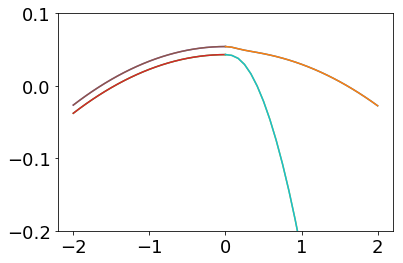

In [24]:
plt.plot(-kz,Ez)
plt.plot(mbkp._kt,Ex)
plt.ylim(-.2,.1)

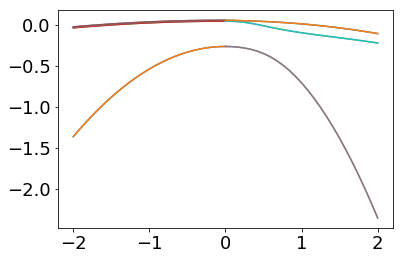

In [25]:
plt.plot(-kz,Ez)
plt.plot(kz,Exz)

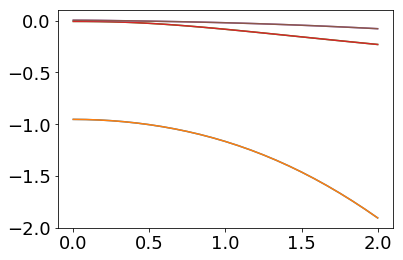

In [30]:
#plt.plot(-kz,Ez)
plt.plot(kz,Exaz)
#plt.ylim(-.1,0)

In [22]:
m.p.integrate(definite=True)/(1/cm**2)  /1e13

Function(4.017983753740012)